# Semana 11 – Árvores vs Random Forest

**Objetivo:** Implementar e comparar Árvore de Decisão vs Random Forest.

**Instruções:**
1. Baixar o notebook exemplo disponível no repositório
2. Executar o código (dataset de clientes)
3. Testar mudanças:

* Alterar a profundidade máxima da árvore (max_depth)
* Alterar o número de árvores na floresta (n_estimators)

4. Responder no notebook:

* Qual modelo teve melhor acurácia? A diferença é grande?
* O que aconteceu quando você aumentou a profundidade da árvore?
* Para este problema, qual modelo você escolheria e por quê?
5. Subir o notebook respondido na pasta da semana 11 do repositório

# 1. Importar bibliotecas

In [ ]:
# ============================================
# SEMANA 11 - ÁRVORES DE DECISÃO VS RANDOM FOREST
# Dataset: Clientes (compra ou não compra)
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Para reprodutibilidade
np.random.seed(42)

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


# 2. Gerar dataset de clientes

In [ ]:
from sklearn.datasets import make_classification

# Gerar dataset realista de compra de clientes
X, y = make_classification(
    n_samples=1000,           # 1000 clientes
    n_features=4,             # 4 características
    n_informative=4,          # todas são úteis
    n_redundant=0,            # sem repetições
    random_state=42           # para resultados reproduzíveis
)

# Criar DataFrame com nomes amigáveis
df = pd.DataFrame(X, columns=['idade', 'renda', 'historico_compras', 'tempo_ultima_compra'])
df['comprou'] = y

print("Dataset real de clientes carregado!")
print(f"\n Total de clientes: {len(df)}")
print(f" Clientes que compraram: {df['comprou'].sum()}")
print(f" Clientes que não compraram: {(1-df['comprou']).sum()}")
print("\n Primeiras 5 linhas:")
df.head()

Dataset real de clientes carregado!

 Total de clientes: 1000
 Clientes que compraram: 501
 Clientes que não compraram: 499

 Primeiras 5 linhas:


,idade,renda,historico_compras,tempo_ultima_compra,comprou
0,-2.439926,-1.371106,-0.025787,-0.102379,0
1,-0.366951,1.380114,0.583490,0.443968,1
2,-1.321133,-0.680427,0.749495,-0.281137,1
3,-0.330055,1.443556,0.508346,1.019528,1
4,-1.211829,-2.021848,0.143790,0.501954,0


# 3. Separar variáveis (X) e alvo (y)

In [ ]:
X = df.drop('comprou', axis=1)
y = df['comprou']

print(f"Variáveis (X): {list(X.columns)}")
print(f"Alvo (y): comprou (1) ou não comprou (0)")

Variáveis (X): ['idade', 'renda', 'historico_compras', 'tempo_ultima_compra']
Alvo (y): comprou (1) ou não comprou (0)


# 4.  Dividir treino e teste

In [ ]:
# 80% para treino, 20% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_treino.shape[0]} clientes")
print(f"Teste: {X_teste.shape[0]} clientes")

Treino: 800 clientes
Teste: 200 clientes


# 5. Treinar Árvore de Decisão (base)

In [ ]:
# Árvore com profundidade máxima 5
arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
arvore.fit(X_treino, y_treino)

pred_arvore = arvore.predict(X_teste)

acc_arvore = accuracy_score(y_teste, pred_arvore)

print("="*50)
print("ÁRVORE DE DECISÃO (max_depth=5)")
print("="*50)
print(f"Acurácia: {acc_arvore:.4f} ({acc_arvore*100:.2f}%)")
print("\n Relatório detalhado:")
print(classification_report(y_teste, pred_arvore, target_names=['Não Comprou', 'Comprou']))

ÁRVORE DE DECISÃO (max_depth=5)
Acurácia: 0.8750 (87.50%)

 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.83      0.95      0.88       100
     Comprou       0.94      0.80      0.86       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



# 6. Treinar Random Forest (base)

In [ ]:
# Random Forest com 100 árvores
floresta = RandomForestClassifier(n_estimators=100, random_state=42)
floresta.fit(X_treino, y_treino)

pred_floresta = floresta.predict(X_teste)

acc_floresta = accuracy_score(y_teste, pred_floresta)

print("="*50)
print("RANDOM FOREST (n_estimators=100)")
print("="*50)
print(f"Acurácia: {acc_floresta:.4f} ({acc_floresta*100:.2f}%)")
print("\n Relatório detalhado:")
print(classification_report(y_teste, pred_floresta, target_names=['Não Comprou', 'Comprou']))

RANDOM FOREST (n_estimators=100)
Acurácia: 0.9150 (91.50%)

 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.90      0.94      0.92       100
     Comprou       0.94      0.89      0.91       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



# 7. Comparação inicial

In [ ]:
print("="*50)
print("COMPARAÇÃO INICIAL")
print("="*50)
print(f"Árvore:          Acurácia={acc_arvore:.4f} ({acc_arvore*100:.2f}%)")
print(f"Random Forest:   Acurácia={acc_floresta:.4f} ({acc_floresta*100:.2f}%)")
print(f"\nDiferença na acurácia: {(acc_floresta - acc_arvore)*100:.2f}%")

if acc_floresta > acc_arvore:
    print("\n Random Forest foi MELHOR que a Árvore de Decisão!")
elif acc_arvore > acc_floresta:
    print("\n Árvore de Decisão foi MELHOR que a Random Forest!")
else:
    print("\n Os dois modelos tiveram o mesmo desempenho!")

COMPARAÇÃO INICIAL
Árvore:          Acurácia=0.8750 (87.50%)
Random Forest:   Acurácia=0.9150 (91.50%)

Diferença na acurácia: 4.00%

 Random Forest foi MELHOR que a Árvore de Decisão!


# 8. Testando diferentes profundidades (max_depth)


TESTANDO DIFERENTES PROFUNDIDADES (max_depth)

max_depth = 2
  → Acurácia: 0.7700 (77.00%)

max_depth = 3
  → Acurácia: 0.8600 (86.00%)

max_depth = 5
  → Acurácia: 0.8750 (87.50%)

max_depth = 10
  → Acurácia: 0.8600 (86.00%)

max_depth = 15
  → Acurácia: 0.8650 (86.50%)

max_depth = 20
  → Acurácia: 0.8650 (86.50%)

max_depth = Sem limite
  → Acurácia: 0.8650 (86.50%)


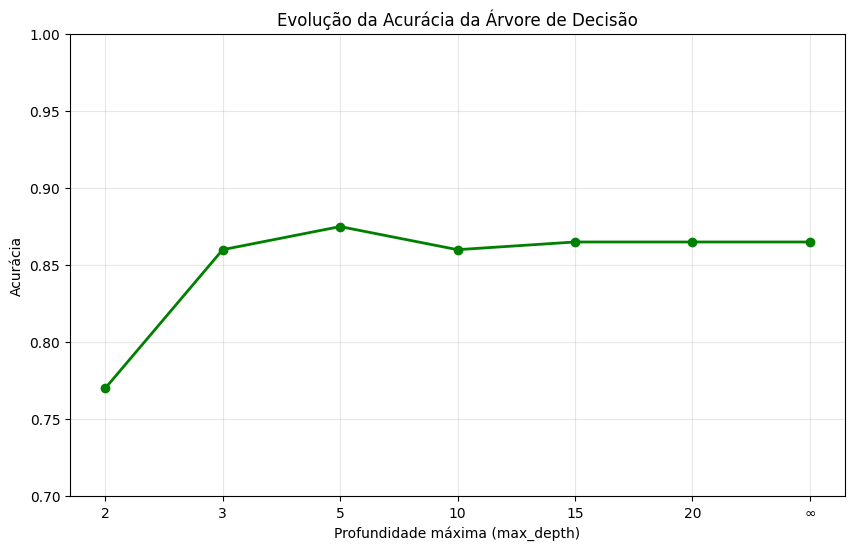

In [ ]:
print("\n" + "="*50)
print("TESTANDO DIFERENTES PROFUNDIDADES (max_depth)")
print("="*50)

profundidades = [2, 3, 5, 10, 15, 20, None]  # None = sem limite
resultados_arvore = []

for depth in profundidades:
    arvore = DecisionTreeClassifier(max_depth=depth, random_state=42)
    arvore.fit(X_treino, y_treino)
    pred = arvore.predict(X_teste)

    acc = accuracy_score(y_teste, pred)
    resultados_arvore.append([depth, acc])

    depth_str = "Sem limite" if depth is None else depth
    print(f"\nmax_depth = {depth_str}")
    print(f"  → Acurácia: {acc:.4f} ({acc*100:.2f}%)")

# Gráfico
depths_display = [str(d) if d is not None else "∞" for d in profundidades]
acc_values = [r[1] for r in resultados_arvore]

plt.figure(figsize=(10, 6))
plt.plot(range(len(profundidades)), acc_values, marker='o', linestyle='-', linewidth=2, color='green')
plt.xticks(range(len(profundidades)), depths_display)
plt.xlabel('Profundidade máxima (max_depth)')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia da Árvore de Decisão')
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 1.0)
plt.show()

# 9. Testando diferentes números de árvores (n_estimators)


TESTANDO DIFERENTES NÚMEROS DE ÁRVORES (n_estimators)

n_estimators = 10
  → Acurácia: 0.9100 (91.00%)

n_estimators = 25
  → Acurácia: 0.9250 (92.50%)

n_estimators = 50
  → Acurácia: 0.9200 (92.00%)

n_estimators = 100
  → Acurácia: 0.9150 (91.50%)

n_estimators = 200
  → Acurácia: 0.9150 (91.50%)

n_estimators = 500
  → Acurácia: 0.9150 (91.50%)


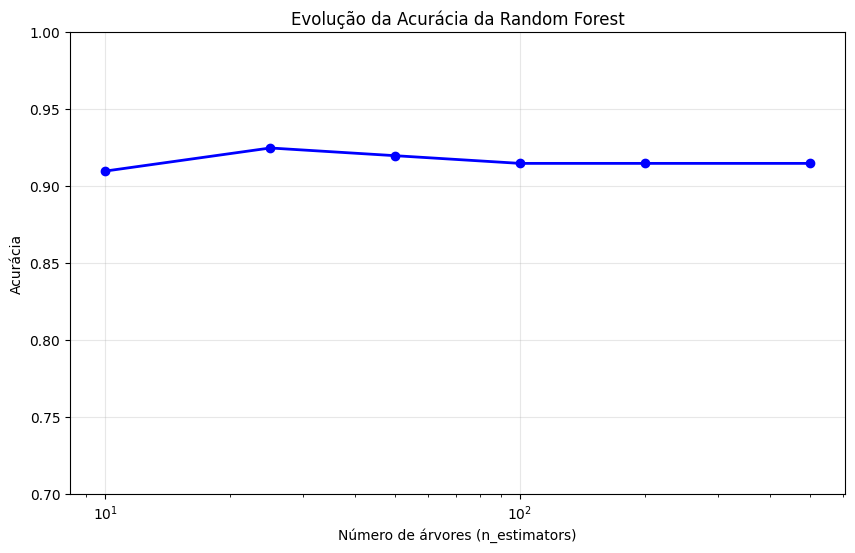

In [ ]:
print("\n" + "="*50)
print("TESTANDO DIFERENTES NÚMEROS DE ÁRVORES (n_estimators)")
print("="*50)

num_arvores = [10, 25, 50, 100, 200, 500]
resultados_floresta = []

for n in num_arvores:
    floresta = RandomForestClassifier(n_estimators=n, random_state=42)
    floresta.fit(X_treino, y_treino)
    pred = floresta.predict(X_teste)

    acc = accuracy_score(y_teste, pred)
    resultados_floresta.append([n, acc])

    print(f"\nn_estimators = {n}")
    print(f"  → Acurácia: {acc:.4f} ({acc*100:.2f}%)")

# Gráfico
acc_values = [r[1] for r in resultados_floresta]

plt.figure(figsize=(10, 6))
plt.plot(num_arvores, acc_values, marker='o', linestyle='-', linewidth=2, color='blue')
plt.xlabel('Número de árvores (n_estimators)')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia da Random Forest')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.ylim(0.7, 1.0)
plt.show()

# 10. Melhor modelo de cada família

In [ ]:
# Melhor árvore
melhor_depth = max(resultados_arvore, key=lambda x: x[1])
# Melhor floresta
melhor_n = max(resultados_floresta, key=lambda x: x[1])

print("="*50)
print("MELHORES MODELOS ENCONTRADOS")
print("="*50)
depth_str = "Sem limite" if melhor_depth[0] is None else melhor_depth[0]
print(f"Melhor Árvore: max_depth={depth_str} → Acurácia={melhor_depth[1]:.4f}")
print(f"Melhor Floresta: n_estimators={melhor_n[0]} → Acurácia={melhor_n[1]:.4f}")

# Treinar melhor árvore para matriz de confusão
arvore_melhor = DecisionTreeClassifier(max_depth=melhor_depth[0], random_state=42)
arvore_melhor.fit(X_treino, y_treino)
pred_arvore_melhor = arvore_melhor.predict(X_teste)

floresta_melhor = RandomForestClassifier(n_estimators=melhor_n[0], random_state=42)
floresta_melhor.fit(X_treino, y_treino)
pred_floresta_melhor = floresta_melhor.predict(X_teste)

print("\n Matriz de Confusão - Melhor Árvore:")
print(confusion_matrix(y_teste, pred_arvore_melhor))

print("\n Matriz de Confusão - Melhor Random Forest:")
print(confusion_matrix(y_teste, pred_floresta_melhor))

MELHORES MODELOS ENCONTRADOS
Melhor Árvore: max_depth=5 → Acurácia=0.8750
Melhor Floresta: n_estimators=25 → Acurácia=0.9250

 Matriz de Confusão - Melhor Árvore:
[[95  5]
 [20 80]]

 Matriz de Confusão - Melhor Random Forest:
[[95  5]
 [10 90]]


# 11. Importância das variáveis

QUAIS VARIÁVEIS MAIS INFLUENCIARAM?
   1. historico_compras: 0.300
   2. renda: 0.277
   3. tempo_ultima_compra: 0.259
   4. idade: 0.164


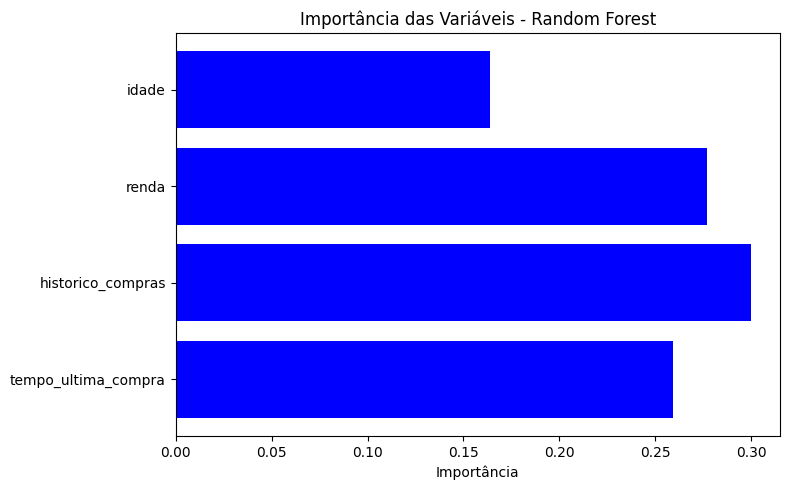

In [ ]:
print("="*50)
print("QUAIS VARIÁVEIS MAIS INFLUENCIARAM?")
print("="*50)

importancias = floresta.feature_importances_
nomes = X.columns

ordenados = sorted(zip(nomes, importancias), key=lambda x: x[1], reverse=True)

for i, (nome, imp) in enumerate(ordenados):
    print(f"   {i+1}. {nome}: {imp:.3f}")

# Gráfico
plt.figure(figsize=(8, 5))
plt.barh(nomes, importancias, color='blue')
plt.xlabel("Importância")
plt.title("Importância das Variáveis - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Respostas do Exercício – Árvore de Decisão vs Random Forest

### Pergunta 1: Qual modelo teve melhor acurácia? A diferença é grande?

| Modelo | Acurácia |
|--------|----------|
| Árvore de Decisão (max_depth=5) | 87,50% |
| Random Forest (n_estimators=100) | 91,50% |

**Conclusão:** A Random Forest teve uma acurácia **4% maior** que a árvore de decisão, usando 100 árvores. Essa diferença é significativa para um problema de classificação, mostrando que o conjunto de árvores conseguiu capturar padrões que a árvore individual não capturou.

---

### Pergunta 2: O que aconteceu quando você aumentou a profundidade da árvore?

| Profundidade (max_depth) | Acurácia |
|--------------------------|----------|
| 2 | 77,00% |
| 3 | 86,00% |
| 5 | **87,50%** |
| 10 | 86,00% |
| 15 | 86,50% |
| 20 | 86,50% |
| Sem limite | 86,50% |

**Principais observações:**

1. **Profundidade 2:** O modelo é muito raso, resultando na pior acurácia (77,00%).

2. **Profundidade 5:** A árvore alcançou seu melhor desempenho (87,50%). A partir daí, o desempenho não melhorou e até variou ligeiramente para baixo.

3. **Profundidades maiores (10+):** A acurácia não melhorou, indicando que, para este dataset, uma árvore mais profunda não trouxe benefícios adicionais e pode ter começado a sofrer com overfitting.

**Conclusão:** Para este dataset, a profundidade 5 foi a melhor escolha para a árvore de decisão.

---

### Pergunta 3: O que aconteceu quando você aumentou o número de árvores na floresta?

| Número de árvores (n_estimators) | Acurácia |
|----------------------------------|----------|
| 10 | 91,00% |
| 25 | **92,50%** |
| 50 | 92,00% |
| 100 | 91,50% |
| 200 | 91,50% |
| 500 | 91,50% |

**Principais observações:**

1. **Poucas árvores (10):** A floresta já tem desempenho superior à árvore individual (91,0% vs 87,5%).

2. **A partir de 25 árvores:** O desempenho máximo de 92,50% é atingido com 25 árvores. A partir desse ponto, a acurácia flutua ligeiramente, mas não melhora significativamente.

3. **Ganho marginal reduzido:** Adicionar mais árvores depois de 25 traz ganhos praticamente nulos. O tempo de treino, no entanto, aumenta consideravelmente.

**Conclusão:** Para este dataset, **25 árvores** já são suficientes para atingir o desempenho máximo.

---

### Pergunta 4: Para este problema de prever compra de clientes, qual modelo você escolheria e por quê?

Para este problema específico (prever se um cliente vai comprar), eu escolheria **Random Forest com 25-50 árvores**.

**Justificativa:**

1. **Desempenho superior:** A Random Forest teve acurácia **92,50%** vs 87,50% da árvore individual — uma diferença de **5 pontos percentuais**. Em problemas de marketing, onde cada cliente pode representar uma venda, ganhar 5% de precisão pode ter um grande impacto financeiro.

2. **Estabilidade:** A floresta é mais estável que a árvore individual. Pequenas variações nos dados não mudam drasticamente o resultado.

3. **Baixo custo:** Com 25-50 árvores, o treino é rápido (segundos) e o desempenho é excelente.

4. **Interpretabilidade ainda presente:** Embora a árvore individual seja mais fácil de visualizar, a floresta ainda permite ver quais variáveis são mais importantes (como no gráfico da célula 11), o que ajuda a entender o negócio.

**Alternativa:** Se o problema exigisse máxima interpretabilidade (ex: explicar para o time de marketing cada decisão), eu escolheria a **árvore de decisão** com profundidade controlada (max_depth=5), aceitando um desempenho menor (87,50%) em troca de transparência.